<a href="https://colab.research.google.com/github/sofiiamyshelova-prog/python_for_ds_tasks/blob/main/Copy_of_HW_2_1_%D0%9B%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B2%D1%96%D0%B4_%D0%B1%D0%B0%D0%B3%D0%B0%D1%82%D1%8C%D0%BE%D1%85_%D0%B7%D0%BC%D1%96%D0%BD%D0%BD%D0%B8%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split




# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
cars_df = pd.read_csv('/content/drive/MyDrive/ML/data/cars.csv')
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [7]:
# Інформація про датафрейм
cars_df.info()

# Типи даних колонок
print(cars_df.dtypes)

# Числові та категоріальні колонки
num_cols = cars_df.select_dtypes(include='number').columns
cat_cols = cars_df.select_dtypes(exclude='number').columns

print(f"\nЧислових колонок: {len(num_cols)}")
print(f"Категоріальних колонок: {len(cat_cols)}")

binary_cols = []
multicat_cols = []

# Аналіз категоріальних колонок
for col in cat_cols:
    print("\n" + "="*50)
    print(f"Колонка: {col}")

    # Унікальні значення
    print("Унікальні значення:")
    print(cars_df.loc[:, col].unique())

    # Кількість унікальних значень
    n_unique = cars_df.loc[:, col].nunique()
    print(f"Кількість унікальних значень: {n_unique}")

    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique > 2:
        multicat_cols.append(col)

print("\nБінарні колонки:")
print(binary_cols)

print("\nМультикатегоріальні колонки:")
print(multicat_cols)

print("\nПІДСУМОК")
print(f"Числових колонок: {len(num_cols)}, з яких одна є ідентифікатором запису")
print(f"Категоріальних колонок: {len(cat_cols)}, з яких")
print(f"Бінарних: {len(binary_cols)}")
print(f"Мультикатегоріальних: {len(multicat_cols)}")
print("можна встановити порядок для колонок: Year, Kilometers_Driven, Mileage, Engine, Power, Seats")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB
Car_ID                int64
Brand                object
Model                object
Year                  int64
Kilometers_Driven     int64


**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [27]:
X = cars_df.drop('Price', axis=1)
y = cars_df['Price']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=12
)

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [28]:
Fuel_Type_isPetrol = {'Petrol': 1, 'Diesel': 0}
X_train['Fuel_Type_isPetrol'] = X_train.Fuel_Type.map(Fuel_Type_isPetrol)
X_test['Fuel_Type_isPetrol'] = X_test.Fuel_Type.map(Fuel_Type_isPetrol)

Transmission_isAutomatic = {'Automatic': 1, 'Manual': 0}
X_train['Transmission_isAutomatic'] = X_train.Transmission.map(Transmission_isAutomatic)
X_test['Transmission_isAutomatic'] = X_test.Transmission.map(Transmission_isAutomatic)

from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Brand']])
one_hot = enc.transform(X_train[['Brand']]).toarray()
X_train[enc.categories_[0]] = one_hot
one_hot = enc.transform(X_test[['Brand']]).toarray()
X_test[enc.categories_[0]] = one_hot

In [ ]:
model_groups = {
    # Passenger cars (sedans, hatchbacks, wagons)
    'Corolla': 'Passenger',
    'Civic': 'Passenger',
    'Mustang': 'Passenger',
    'Swift': 'Passenger',
    'Sonata': 'Passenger',
    'Polo': 'Passenger',
    'A4': 'Passenger',
    'C-Class': 'Passenger',
    'City': 'Passenger',
    '5 Series': 'Passenger',
    'Figo': 'Passenger',
    'Verna': 'Passenger',
    'Altroz': 'Passenger',
    'Passat': 'Passenger',
    'A6': 'Passenger',
    'E-Class': 'Passenger',
    'Aspire': 'Passenger',
    'Elantra': 'Passenger',
    'Yaris': 'Passenger',
    'Santro': 'Passenger',
    'Tigor': 'Passenger',
    'Ameo': 'Passenger',
    'A3': 'Passenger',
    '7 Series': 'Passenger',
    'Camry': 'Passenger',
    'Tiago': 'Passenger',
    'Vento': 'Passenger',
    'A5': 'Passenger',
    '3 Series': 'Passenger',

    # SUVs and Crossovers
    'Nexon': 'SUV',
    'Scorpio': 'SUV',
    'X1': 'SUV',
    'Endeavour': 'SUV',
    'Creta': 'SUV',
    'Harrier': 'SUV',
    'Tiguan': 'SUV',
    'Q3': 'SUV',
    'Thar': 'SUV',
    'Safari': 'SUV',
    'Vitara': 'SUV',
    'WR-V': 'SUV',
    'BR-V': 'SUV',
    'T-Roc': 'SUV',
    'Q7': 'SUV',
    'X5': 'SUV',
    'GLA': 'SUV',
    'Venue': 'SUV',
    'XUV300': 'SUV',
    'X3': 'SUV',
    'GLE': 'SUV',
    'GLC': 'SUV',
    'EcoSport': 'SUV',
    'S-Cross': 'SUV',
    'Fortuner': 'SUV',

    # MPVs and Pickups
    'Ertiga': 'MPV/Pickup',
    'Innova': 'MPV/Pickup',
    'Innova Crysta': 'MPV/Pickup',
    'Ranger': 'MPV/Pickup'
}

X_train['Model_Group'] = X_train['Model'].map(model_groups)
X_test['Model_Group'] = X_test['Model'].map(model_groups)

enc.fit(X_train[['Model_Group']])
one_hot = enc.transform(X_train[['Model_Group']]).toarray()
X_train[enc.categories_[0]] = one_hot
one_hot = enc.transform(X_test[['Model_Group']]).toarray()
X_test[enc.categories_[0]] = one_hot

In [29]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [32]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_isPetrol,Transmission_isAutomatic,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Model_Group,MPV/Pickup,Passenger,SUV,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SUV,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Passenger,0.0,1.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Passenger,0.0,1.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Passenger,0.0,1.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,SUV,0.0,0.0,1.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_isPetrol,Transmission_isAutomatic,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Model_Group,MPV/Pickup,Passenger,SUV,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SUV,0.0,0.0,1.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Passenger,0.0,1.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Passenger,0.0,1.0,0.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,MPV/Pickup,1.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Passenger,0.0,1.0,0.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [35]:
X_train = X_train.select_dtypes(include=['int64', 'float64'])
X_train.head()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_isPetrol,Transmission_isAutomatic,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,MPV/Pickup,Passenger,SUV,Owner_Type_Codes
83,84,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
55,56,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
26,27,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
54,55,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
19,20,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [37]:
cars_df_num = pd.concat([X_train, y_train], axis=1)
cars_df_num.head()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_isPetrol,Transmission_isAutomatic,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,MPV/Pickup,Passenger,SUV,Owner_Type_Codes,Price
83,84,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1600000
55,56,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2600000
26,27,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3200000
54,55,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,650000
19,20,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2500000


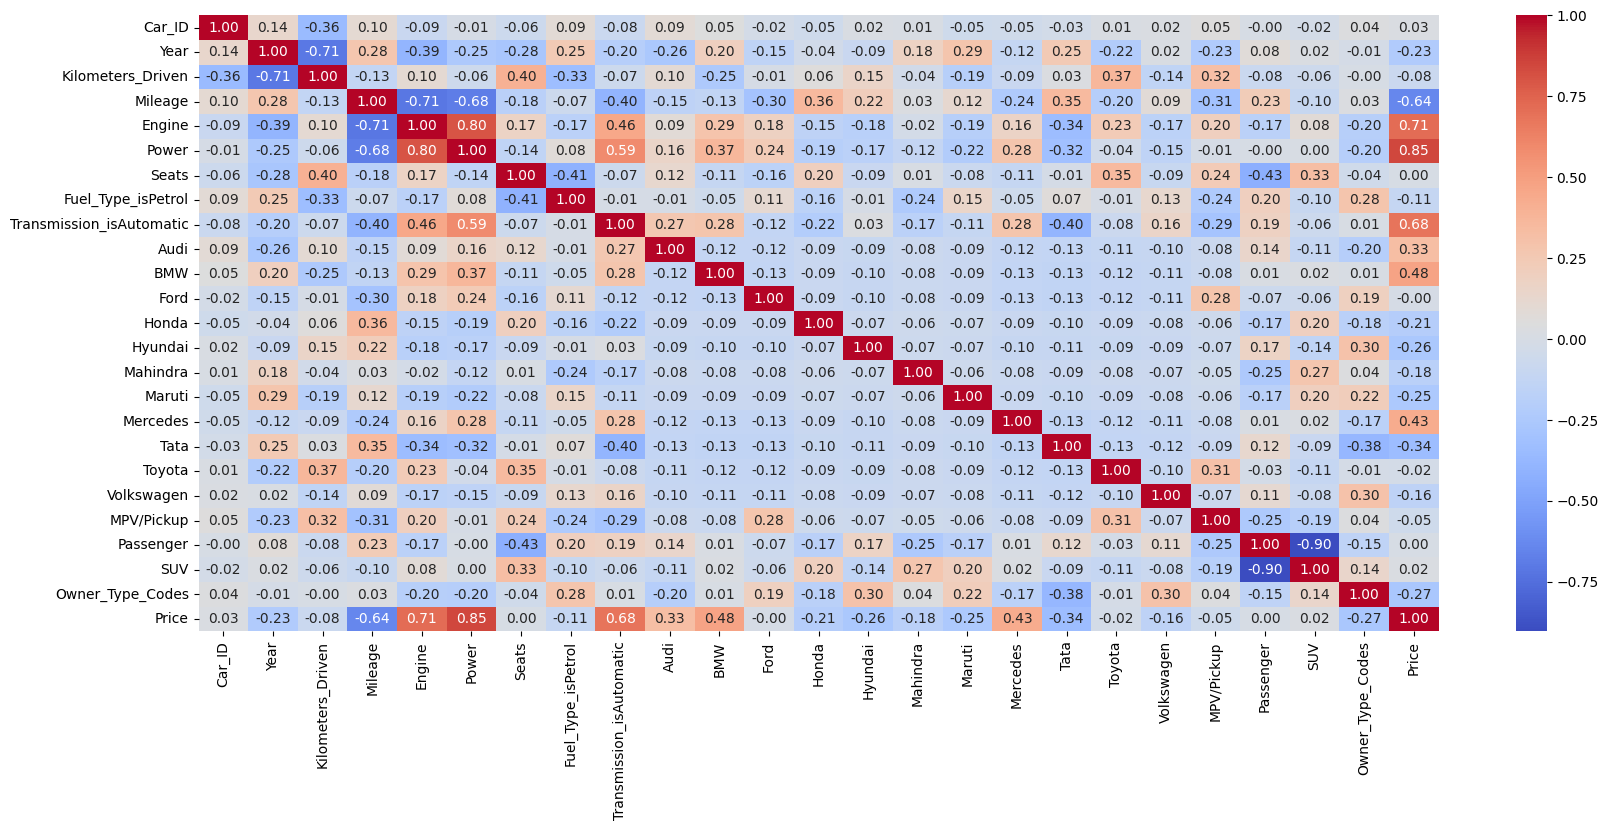

In [43]:
corr_matrix = cars_df_num.corr()


plt.figure(figsize=(20, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

З цільовою змінною сильну позитивну кореляцію мають колонки: Engine, Power, Transmission_isAutomatic
негативну кореляцію мають колонки: Mileage

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

Loss train: 202980.18249140354
Loss test: 276165.0007547457


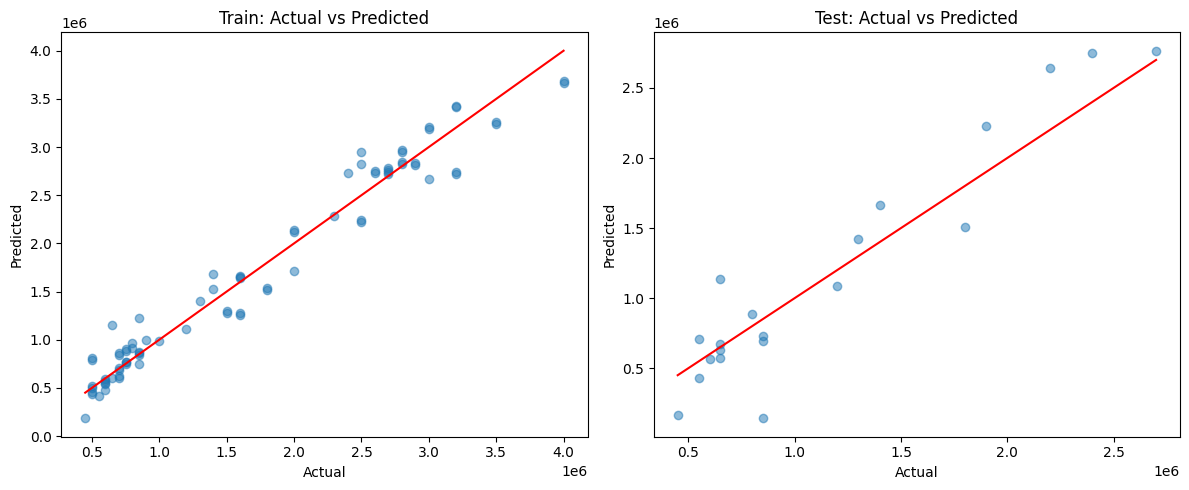

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_test = X_test.select_dtypes(include=['int64', 'float64'])

# Створюємо і одразу тренуємо модель
model = LinearRegression().fit(X_train, y_train)

# Робимо передбачення моделлю
y_train_predictions = model.predict(X_train)
y_test_predictions = model.predict(X_test)

# Разуємо лосс
loss = np.sqrt(mean_squared_error(y_train, y_train_predictions))
print('Loss train:', loss)

loss = np.sqrt(mean_squared_error(y_test, y_test_predictions))
print('Loss test:', loss)

plt.figure(figsize=(12, 5))

# TRAIN
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_predictions, alpha=0.5)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red')
plt.title("Train: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")

# TEST
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.title("Test: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

Маємо досить великі loss 200+тисяч, але так як цілова змінна теж велика, то loss до 15% і для простої регресії це нормально.
На графіках видно, що точки знаходяться недалеко від лінії y=x, тобто передбачення більш-менш нормальне, але хотілось би більш точного.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_train.columns,
    index=X_test.index
)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

coefficients = pd.DataFrame({
    "feature": X_train.columns,
    "coef": model.coef_
})

coefficients["abs_coef"] = coefficients["coef"].abs()
coefficients = coefficients.sort_values("abs_coef", ascending=False)

top_features = coefficients.head(10)
print(top_features)

               feature           coef       abs_coef
5                Power  472304.222388  472304.222388
9                 Audi  214872.467286  214872.467286
16            Mercedes  212635.241277  212635.241277
10                 BMW  210953.205546  210953.205546
7   Fuel_Type_isPetrol -195912.307380  195912.307380
14            Mahindra -165621.139308  165621.139308
13             Hyundai -148195.529189  148195.529189
3              Mileage -141645.053320  141645.053320
15              Maruti -124270.864429  124270.864429
11                Ford -103409.380152  103409.380152


Найбільш впливова фіча - Power. Чим більш потужне авто, тим дорожче. Це логічно.

Бачимо, що бренди також сильно впливають на ціну, чого не було видно в матриці кореляції.
Дорогі бренди Audi, Mersedes, BMW. Дешеві бренди: Mahindra, Hyundai, Maruti, Ford. Це логічно, бо бренди розділились на преміальні дорожчі та масові дешевші.

Тип палива також впливає - бензинові авто дешевші. Напевно це залежить від ринку, і за нашими даними бензинові авто в Індії дешевші.

Розхід палива Mileage оберненопропорційний до ціни. Це пов'язано з тим, що більш економні авто - це переважно масові бренди для середнього класу, тому для великого Mileage нижча ціна.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [61]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_scaled)
model_sm = sm.OLS(y_train, X_train_sm).fit()

print(model_sm.summary())

significant_features = model_sm.pvalues[model_sm.pvalues < 0.05]
significant_features = significant_features.drop('const', errors='ignore')

print(significant_features)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     64.63
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           1.88e-32
Time:                        17:19:09   Log-Likelihood:                -1091.2
No. Observations:                  80   AIC:                             2228.
Df Residuals:                      57   BIC:                             2283.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

Бачимо ту ж картину значущих колонок, що і в попередньому завданні. Також додалась ознака Transmission_isAutomatic, що також є логічним, бо авто з автоматичною коробкою передач дорожчі.

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [62]:
significant_features = model_sm.pvalues[model_sm.pvalues < 0.05]
significant_features = significant_features.drop('const', errors='ignore')
#записуємо назви фіч
selected_cols = significant_features.index

X_train_sig = X_train_scaled[selected_cols]
X_test_sig = X_test_scaled[selected_cols]

X_train_sig_sm = sm.add_constant(X_train_sig)

model_sig = sm.OLS(y_train, X_train_sig_sm).fit()

print(model_sig.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     97.34
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           5.66e-38
Time:                        17:28:02   Log-Likelihood:                -1097.8
No. Observations:                  80   AIC:                             2226.
Df Residuals:                      65   BIC:                             2261.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [63]:
print("FULL MODEL:")
print("R2:", model_sm.rsquared)
print("Adj R2:", model_sm.rsquared_adj)

print("\nREDUCED MODEL:")
print("R2:", model_sig.rsquared)
print("Adj R2:", model_sig.rsquared_adj)

FULL MODEL:
R2: 0.9614552599167439
Adj R2: 0.9465783426916274

REDUCED MODEL:
R2: 0.9544754234363119
Adj R2: 0.9446701300225944


R2 і Adj. R-squared майже не змінились, отже ми зробили модель менш навантаженою, але не втратили точности.

Менш навантажена модель  має R2 = 0.954, Adj. R2 = 0.945, що свідчить про її ефективність у прогнозуванні ціни автомобіля.

Статистичний F-тест показує значущість моделі в цілому.

Найбільш впливовими змінними є потужність двигуна, бренд автомобіля та тип коробки передач. Преміальні бренди (Audi, BMW, Mercedes) мають позитивний вплив на ціну, тоді як масові бренди знижують її.

Діагностичні тести підтверджують коректність моделі: залишки нормально розподілені, автокореляція відсутня.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [64]:
significant_features = model_sm.pvalues[model_sm.pvalues < 0.25]
significant_features = significant_features.drop('const', errors='ignore')
#записуємо назви фіч
selected_cols = significant_features.index

X_train_sig = X_train_scaled[selected_cols]
X_test_sig = X_test_scaled[selected_cols]

X_train_sig_sm = sm.add_constant(X_train_sig)

model_sig = sm.OLS(y_train, X_train_sig_sm).fit()

print(model_sig.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     89.32
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           5.28e-37
Time:                        17:34:31   Log-Likelihood:                -1094.8
No. Observations:                  80   AIC:                             2224.
Df Residuals:                      63   BIC:                             2264.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

R2 і Adj. R-squared майже не змінились, але ми зробили модель більш навантаженою та збільшили ризик того, що не дуже значущі ознаки будуть впливати на таргет.
Краще залишити попередню модель з pvalues < 0.05